Blocks to select an interval of water level data from the eo-tides results and PUV data, interpolate to common timestamps, and various plots. The PUV "water_variation" is corrected against the mean of water depth readings of the PUV sensor.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import pandas as pd
import numpy as np
import seaborn as sns

# Load Data
df_sig = pd.read_csv("sig1000_waves.csv")
df_tide = pd.read_csv("tidal_data_marconi_modelled_2024-10-01-2025-03-31.csv")

df_sig["time"] = pd.to_datetime(df_sig["time"])
df_tide["time"] = pd.to_datetime(df_tide["time"])

# Define interval of interest
start_time = df_sig["time"].min()
end_time = df_tide["time"].max()
df_tide = df_tide[df_tide["time"].between(start_time, end_time)].copy()

df_tide.columns = [
    "time",
    "FES2022_heightm",
    "EOT20_heightm",
    "GOT5.5_heightm",
    "GOT5.6_heightm",
    "FES2022_stage",
    "EOT20_stage",
    "GOT5.5_stage",
    "GOT5.6_stage",
]

# Subtract mean water depth from PUV sensor water depth
df_sig["water_depth_mean"] = df_sig["water_depth"].mean()
df_sig["water_variation"] = df_sig["water_depth"] - df_sig["water_depth_mean"]

# Sort dataframes by time (Required for interpolation/merging)
df_tide = df_tide.sort_values("time")
df_sig = df_sig.sort_values("time")

# --- INTERPOLATION FIXED ---
columns = ["FES2022_heightm", "EOT20_heightm", "GOT5.5_heightm", "GOT5.6_heightm"]

known_times = df_tide["time"].astype("int64")
target_times = df_sig["time"].astype("int64")

# 1. Initialize the empty dictionary/dataframe to hold your results
df_interp = pd.DataFrame(index=df_sig.index)

for column in columns:
    known_values = pd.to_numeric(df_tide[column], errors="coerce")
    # 2. Map target values using numpy interpolation
    interpolated_values = np.interp(target_times, known_times, known_values)
    df_interp[column + "_interp"] = interpolated_values

# 3. Use axis=1 to concatenate side-by-side (columns), not top-to-bottom (rows)
df_new = pd.concat([df_sig, df_interp], axis=1)
df_new.to_csv("tidal_data_marconi_modelled_2024-10-01-2025-03-31_interp2sig.csv")


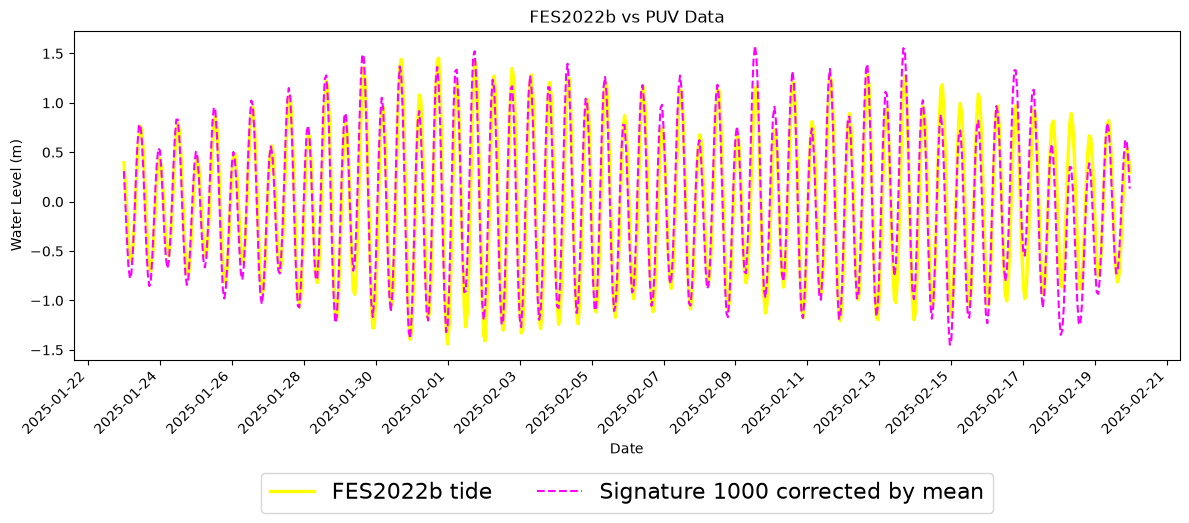

<Figure size 640x480 with 0 Axes>

In [7]:
# Lineplots of PUV "tidal" signal and modelled tides using FES2022b
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(df_new["time"],df_new["FES2022_heightm_interp"],label="FES2022b tide",color='yellow',linewidth=2.4) # convert from cm
ax.plot(df_sig["time"],df_sig["water_variation"],linestyle="--",color='magenta',label = "Signature 1000 corrected by mean")

# Set daily ticks and format
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # every day
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.50),ncol=4,fontsize = 16)
ax.set_xlabel("Date")
ax.set_ylabel("Water Level (m)")
ax.set_title("FES2022b vs PUV Data")
plt.tight_layout()
plt.show()

plt.savefig(f'PUV-FES2022-Timeseries-01232025-02192025.png')

                   time   wh_4061   wp_peak  wvdir  water_depth  \
0   2025-01-23 00:00:00  0.863452  5.847953   70.0    21.358337   
1   2025-01-23 01:00:00  0.826128  5.847953   74.0    21.028902   
2   2025-01-23 02:00:00  0.806027  5.361930   64.0    20.666761   
3   2025-01-23 03:00:00  0.836741  5.847953   78.0    20.400822   
4   2025-01-23 04:00:00  0.707249  5.361930   74.0    20.270443   
..                  ...       ...       ...    ...          ...   
667 2025-02-19 19:00:00  0.719395  4.950495    0.0    21.498386   
668 2025-02-19 20:00:00  0.707143  4.950495    2.0    21.671345   
669 2025-02-19 21:00:00  0.611404  4.597701  358.0    21.668020   
670 2025-02-19 22:00:00  0.551917  4.597701    2.0    21.486097   
671 2025-02-19 23:00:00  0.470908  4.291845    2.0    21.181028   

     water_depth_mean  water_variation  FES2022_heightm_interp  \
0           21.049527         0.308810                0.393310   
1           21.049527        -0.020625                0.172476 

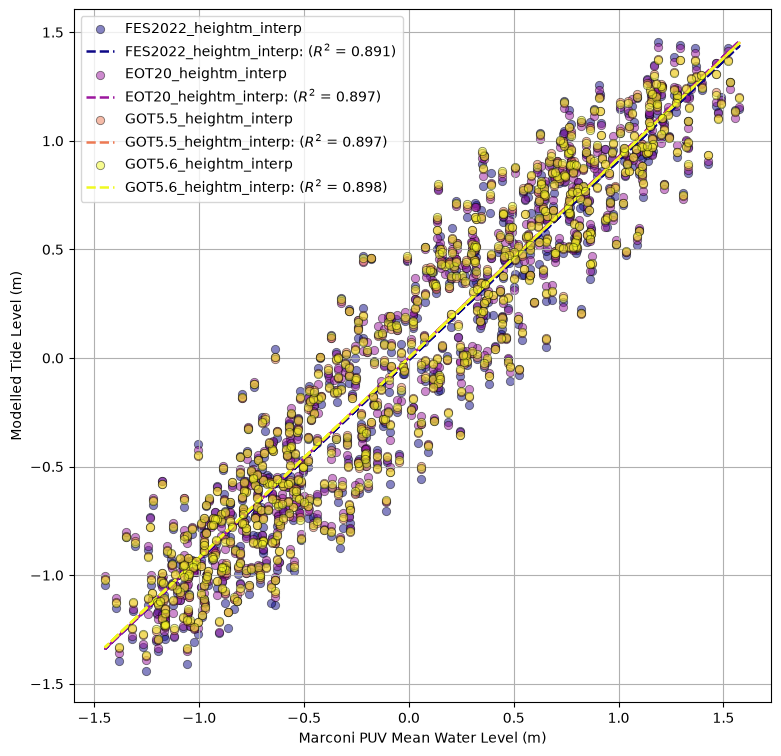

In [10]:
# Scatterplot of Modelled Tides vs PUV water levels, with regression
fig, ax = plt.subplots(figsize=(9,9))
print(df_new)
cmap = plt.colormaps['plasma'] 
columns = df_interp.columns[df_interp.columns.str.contains("_interp")]
for i in range(len(columns)):
    x = df_new['water_variation']
    y = df_new[columns[i]]
    
    color = cmap(i / (len(columns) - 1)) 
    m, b = np.polyfit(x, y, deg=1)

    y_pred = m * x + b
    ss_res = np.sum((y - y_pred) ** 2)       # Residual sum of squares [1, 2]
    ss_tot = np.sum((y - np.mean(y)) ** 2)   # Total sum of squares [1, 2]
    r_squared = 1 - (ss_res / ss_tot)        # R² Formula [1, 2]
    label_text = f'{columns[i]}: ($R^2$ = {r_squared:.3f})'
    ax.scatter(x, y, color=color, label=f'{columns[i]}',edgecolors="black",linewidths=0.6,alpha=0.5,zorder=i)
    ax.plot(x, m * x + b, color=color, linewidth=1.8, linestyle='--',label=label_text)

plt.xlabel('Marconi PUV Mean Water Level (m)')
plt.ylabel('Modelled Tide Level (m)')
plt.legend()
plt.grid(True,zorder = 0)
plt.show

plt.savefig('CrossPlot_FES2022-PUV_01232025-02192025.png')



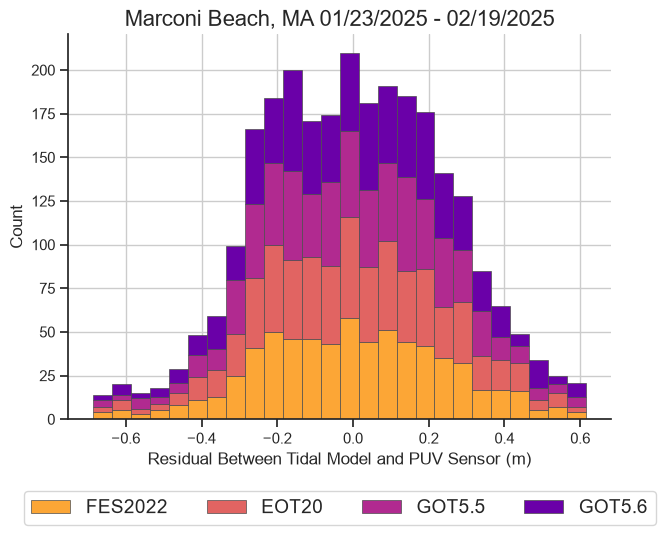

In [34]:
import seaborn as sns
df_diff = pd.DataFrame()

for i in range(len(columns)):
    x = df_new['water_variation']
    y = df_new[columns[i]]
    z = x-y
    df_diff[f"{columns[i]}_diff"] = z

sns.set_theme(style="ticks")

f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)


sns.histplot(
    data=df_diff,
    multiple="stack",
    palette="plasma",
    kde=False,
    stat="count",
    edgecolor=".3",
    linewidth=.5,
    log_scale=False,
    alpha = 1,
    legend=True
)
plt.grid(True)
plt.box(True)
plt.xlabel("Residual Between Tidal Model and PUV Sensor (m)")
plt.title('Marconi Beach, MA 01/23/2025 - 02/19/2025',size=16)
plt.legend(ncol=4, labels = ['FES2022','EOT20','GOT5.5','GOT5.6'],loc='lower center',bbox_to_anchor=(0.5,-0.3),fontsize=14)

plt.savefig('Marconi_PUV-v-Modelled-Tide_01232025-02192025.png')